# 4 · Tree spaces: structured elements and block operators

Not every unknown is a flat vector. A saddle-point system has a *primal* block and a *dual*
block of different sizes; a PDE solve might carry a field plus a handful of scalar multipliers.
A **`TreeSpace`** is the direct product of heterogeneous leaf spaces, organised as a Python
tree (a tuple, list, dict, or `NamedTuple`). Its elements are trees of arrays; its inner
product is the **sum of the leaf inner products**; and **block operators** map one tree space
to another.

We will assemble a $2\times 2$ block SPD system

$$ \begin{pmatrix} A & B^\top \\ B & D \end{pmatrix}
   \begin{pmatrix} u \\ p \end{pmatrix} =
   \begin{pmatrix} f \\ g \end{pmatrix}, $$

with $u \in \mathbb{R}^2$ and $p \in \mathbb{R}^1$ living in different leaves, and solve it
with `sc.cg` directly over the tree space.

**You will learn to** build a `TreeSpace` and `TreeElement`, compose blocks with
`BlockMatrixLinOp`, and run a Krylov solver over structured unknowns.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import spacecore as sc

# A clean, consistent palette + style for every figure in the tutorials.
BLUE, INDIGO, CYAN = "#2563eb", "#4f46e5", "#0891b2"
PINK, AMBER, GREEN = "#db2777", "#d97706", "#059669"
SLATE, GRID = "#334155", "#e5e9f0"

mpl.rcParams.update({
    "figure.figsize": (7.2, 4.2), "figure.dpi": 120, "savefig.dpi": 120,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": SLATE, "axes.linewidth": 1.0,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": SLATE,
    "axes.labelcolor": SLATE, "axes.labelsize": 11,
    "xtick.color": SLATE, "ytick.color": SLATE,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "font.size": 11,
    "legend.frameon": False, "legend.fontsize": 10,
    "lines.linewidth": 2.4, "lines.markersize": 6, "image.cmap": "magma",
})
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(
    color=[BLUE, PINK, GREEN, AMBER, INDIGO, CYAN])

print("spacecore", sc.__version__, "| numpy", np.__version__)

spacecore 0.4.0 | numpy 2.4.2


In [2]:
ctx = sc.Context(sc.NumpyOps(), dtype=np.float64)

## 1 · A space made of spaces

`TreeSpace.from_leaf_spaces((X, S))` glues leaf spaces into a tuple-structured product. An
element is just a tuple `(u, p)` of leaf arrays.

In [3]:
X = sc.DenseVectorSpace((2,), ctx)        # primal leaf  u ∈ ℝ²
S = sc.DenseVectorSpace((1,), ctx)        # dual leaf    p ∈ ℝ¹
T = sc.TreeSpace.from_leaf_spaces((X, S), ctx)

u = (ctx.asarray([1.0, 2.0]), ctx.asarray([3.0]))
v = (ctx.asarray([4.0, 5.0]), ctx.asarray([6.0]))

print("leaf paths :", T.leaf_paths)
print("<u, v>_T   :", T.inner(u, v), " (= 1·4 + 2·5 + 3·6 — sum over leaves)")
print("||u||_T    :", T.norm(u))
print("flatten    :", T.flatten(u), " (tree → one dense vector)")
print("zeros      :", T.zeros())

el = sc.TreeElement(T, u)                 # an explicit element bound to its space
print("element    :", el.value)

leaf paths : ((0,), (1,))
<u, v>_T   : 32.0  (= 1·4 + 2·5 + 3·6 — sum over leaves)
||u||_T    : 3.7416573867739413
flatten    : [1. 2. 3.]  (tree → one dense vector)
zeros      : (array([0., 0.]), array([0.]))
element    : (array([1., 2.]), array([3.]))


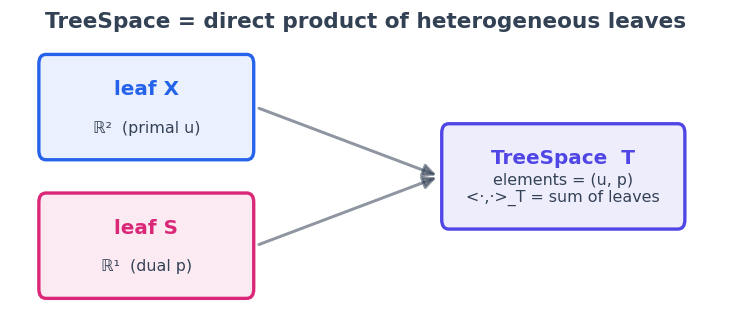

In [4]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
fig, ax = plt.subplots(figsize=(7.6, 3.0)); ax.axis("off")
ax.set_xlim(0, 10); ax.set_ylim(0, 3)

def box(x, y, w, h, t, s, color):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.1",
                 lw=2, edgecolor=color, facecolor=color + "18"))
    ax.text(x+w/2, y+h*0.62, t, ha="center", fontsize=12, fontweight="bold", color=color)
    ax.text(x+w/2, y+h*0.25, s, ha="center", fontsize=9.5, color=SLATE)

box(0.4, 1.7, 3.0, 1.1, "leaf X", "ℝ²  (primal u)", BLUE)
box(0.4, 0.2, 3.0, 1.1, "leaf S", "ℝ¹  (dual p)", PINK)
box(6.1, 0.95, 3.4, 1.1, "TreeSpace  T", "elements = (u, p)\n<·,·>_T = sum of leaves", INDIGO)
for y in (2.25, 0.75):
    ax.add_patch(FancyArrowPatch((3.45, y), (6.05, 1.5), arrowstyle="-|>",
                 mutation_scale=16, lw=1.8, color=SLATE, alpha=0.55))
ax.set_title("TreeSpace = direct product of heterogeneous leaves", loc="center")
plt.show()

## 2 · Block operators over the tree

Each block is an ordinary `DenseLinOp` between leaves; `BlockMatrixLinOp` arranges them into a
single map $T \to T$ with $y_i = \sum_j A_{ij}\, x_j$.

In [5]:
Amat = np.array([[4.0, 1.0], [1.0, 3.0]])     # X → X
Bmat = np.array([[1.0, 2.0]])                  # X → S
Dmat = np.array([[10.0]])                      # S → S

A_op  = sc.DenseLinOp(ctx.asarray(Amat),   X, X, ctx)
Bt_op = sc.DenseLinOp(ctx.asarray(Bmat.T), S, X, ctx)   # Bᵀ : S → X
B_op  = sc.DenseLinOp(ctx.asarray(Bmat),   X, S, ctx)   # B  : X → S
D_op  = sc.DenseLinOp(ctx.asarray(Dmat),   S, S, ctx)

M = sc.BlockMatrixLinOp([[A_op, Bt_op],
                         [B_op, D_op]])
print("M : T → T  square?", M.dom == M.cod)
print("M·(u,p)         :", M.apply((ctx.asarray([1.0, 0.0]), ctx.asarray([1.0]))))

M : T → T  square? True
M·(u,p)         : (array([5., 3.]), array([11.]))


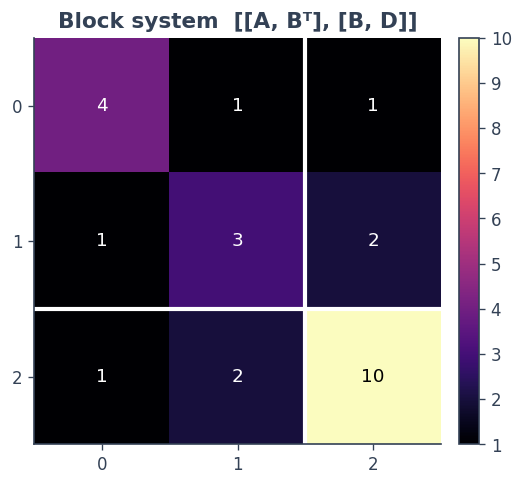

eigenvalues: [ 2.165  4.081 10.755] → SPD, so CG applies


In [6]:
full = np.block([[Amat, Bmat.T], [Bmat, Dmat]])     # dense reference, for the picture
fig, ax = plt.subplots(figsize=(4.8, 4.4))
im = ax.imshow(full, cmap="magma")
for i in range(full.shape[0]):
    for j in range(full.shape[1]):
        ax.text(j, i, f"{full[i,j]:.0f}", ha="center", va="center",
                color="white" if full[i,j] < 7 else "black", fontsize=11)
# block separators between the X (size 2) and S (size 1) leaves
ax.axhline(1.5, color="white", lw=2.5); ax.axvline(1.5, color="white", lw=2.5)
ax.set_xticks(range(3)); ax.set_yticks(range(3)); ax.grid(False)
ax.set_title("Block system  [[A, Bᵀ], [B, D]]")
fig.colorbar(im, fraction=0.046, pad=0.04); plt.show()
print("eigenvalues:", np.round(np.linalg.eigvalsh(full), 3), "→ SPD, so CG applies")

## 3 · Solve it with conjugate gradients over the tree

`sc.cg` does not care that the unknown is a tree — it only needs `M.apply` and the tree
inner product. The right-hand side and the solution are tree elements.

In [7]:
b = (ctx.asarray([1.0, -2.0]), ctx.asarray([0.5]))     # RHS as a tree element
res = sc.cg(M, b, tol=1e-12, maxiter=50)

print("converged :", bool(res.converged), " iterations:", int(res.num_iters))
print("u block   :", res.x[0])
print("p block   :", res.x[1])

# cross-check against a plain dense solve on the flattened system
ref = np.linalg.solve(full, np.array([1.0, -2.0, 0.5]))
print("matches dense solve:", np.allclose(T.flatten(res.x), ref))

converged : True  iterations: 4
u block   : [ 0.43684211 -0.94210526]
p block   : [0.19473684]
matches dense solve: True


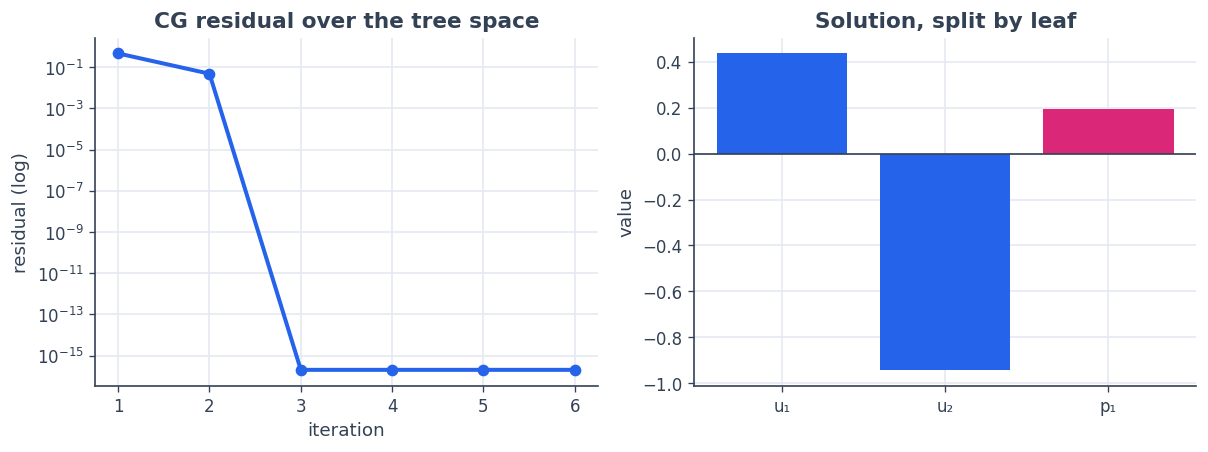

In [8]:
ks = np.arange(1, 7)
hist = [float(sc.cg(M, b, tol=0.0, atol=0.0, maxiter=int(k), check_every=1).residual_norm)
        for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.9))
axes[0].semilogy(ks, hist, color=BLUE, marker="o")
axes[0].set_title("CG residual over the tree space"); axes[0].set_xlabel("iteration")
axes[0].set_ylabel("residual (log)")

labels = ["u₁", "u₂", "p₁"]
axes[1].bar(labels, T.flatten(res.x), color=[BLUE, BLUE, PINK])
axes[1].axhline(0, color=SLATE, lw=1)
axes[1].set_title("Solution, split by leaf"); axes[1].set_ylabel("value")
plt.tight_layout(); plt.show()

The two `u` bars (blue) and the `p` bar (pink) come back in their own leaves — the solver
never flattened your problem into an anonymous vector.

## 4 · Named blocks

A tuple tree is fine, but the blocks here *mean* something — a primal **state** and a dual
**multiplier**. A `TreeSpace` can carry that naming: build it from a `NamedTuple` template with
`from_template`, and elements round-trip as that type, so you read blocks **by name** instead of
by position. The geometry, operators, and solvers are exactly the same — only your access
pattern changes.

In [9]:
from typing import NamedTuple

class KKT(NamedTuple):
    state: object        # the u block, in X = ℝ²
    multiplier: object   # the p block, in S = ℝ¹

T_named = sc.TreeSpace.from_template(KKT(0, 0), (X, S), ctx=ctx)

xb = T_named.element(KKT(state=ctx.asarray([1.0, 2.0]),
                         multiplier=ctx.asarray([3.0])))

print("element type :", type(xb.value).__name__)         # KKT — the original type
print("read by name :", xb.value.state, "|", xb.value.multiplier)
print("inner         :", T_named.inner(xb.value, xb.value))
print("same as tuple :", float(T_named.inner(xb.value, xb.value))
                          == float(T.inner((xb.value.state, xb.value.multiplier),
                                           (xb.value.state, xb.value.multiplier))))

element type : KKT
read by name : [1. 2.] | [3.]
inner         : 14.0
same as tuple : True


Dicts work as well — ``sc.TreeSpace({"state": 0, "multiplier": 0}, (X, S), ctx=ctx)`` — with
one caveat: dict leaves are ordered by **sorted key**, so check ``T.leaf_paths`` to confirm how
``leaf_spaces`` pairs up. A `NamedTuple` keeps your declared field order, which is usually what
you want.

## Recap

* A **`TreeSpace`** is a direct product of heterogeneous leaves; elements are Python trees and
  `inner`/`norm` sum over leaves. `flatten`/`unflatten` bridge to a plain vector.
* **`BlockMatrixLinOp`** (and friends `BlockDiagonalLinOp`, `StackedLinOp`,
  `SumToSingleLinOp`) compose leaf operators into maps between tree spaces.
* Solvers like **`sc.cg`** run unchanged over tree spaces — structure is preserved end to end.

**Next:** [5 · Weighted Tikhonov](05_weighted_tikhonov.ipynb) — a worked inverse problem where
the *metric adjoint* does the heavy lifting.